In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
airline = pd.read_csv("data/airline_passengers.csv", index_col="Month")
airline.dropna(inplace=True) # clean index before transform it into datetime
airline.index = pd.to_datetime(airline.index)
airline.index.freq = "MS" # normally it infers automatically, but better to specify. MS indicates the data contains info of the Month Start
airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [9]:
span = 12
alpha = 2/(span + 1)
airline["EWMA12"] = airline["Thousands of Passengers"].ewm(alpha=alpha, adjust=False).mean()

In [18]:
airline.head()

,Thousands of Passengers,EWMA12
Month,,
1949-01-01,112,112.000000
1949-02-01,118,112.923077
1949-03-01,132,115.857988
1949-04-01,129,117.879836
1949-05-01,121,118.359861


In [19]:
model = SimpleExpSmoothing(airline["Thousands of Passengers"])
fitted_model = model.fit(smoothing_level=alpha, optimized=False)
fitted_model.fittedvalues.head() # since we have set optimized=False, the first two values are repeated, but the values are the same as in EWMA

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    112.923077
1949-04-01    115.857988
1949-05-01    117.879836
Freq: MS, dtype: float64

In [27]:
# simple exponential smoothing (equivalent to EWMA)
airline["SES12"] = fitted_model.fittedvalues.shift(-1) # to remove the duplicate at the beginning

<Axes: xlabel='Month'>

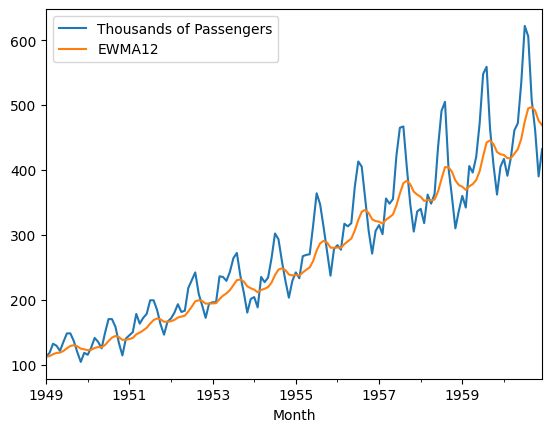

In [22]:
airline.plot()

<Axes: xlabel='Month'>

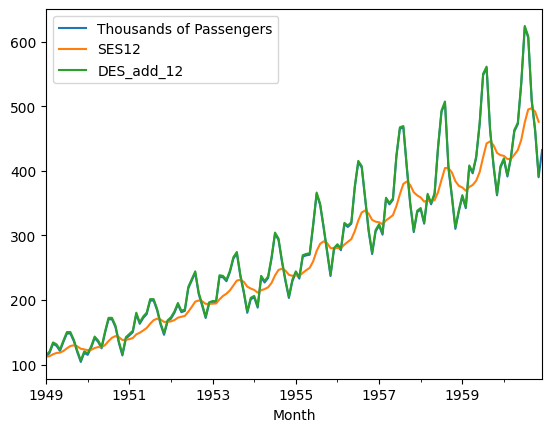

In [ ]:
# Double Exponential Smoothing
# We will use add from additive since it seems linear tendency more than exponential
airline["DES_add_12"] = ExponentialSmoothing(airline["Thousands of Passengers"], trend="add").fit().fittedvalues.shift(-1)

# we can see that just with the addition of one more term, we can are able to express or replicate complex data, and much better than with 1 parameter
airline[["Thousands of Passengers", "SES12", "DES_add_12"]].plot()

<Axes: xlabel='Month'>

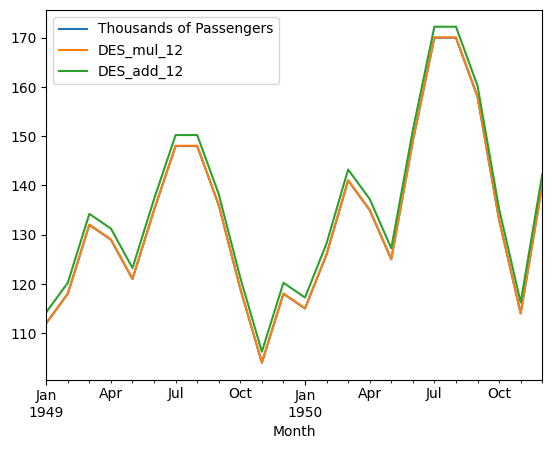

In [ ]:
airline["DES_mul_12"] = ExponentialSmoothing(airline["Thousands of Passengers"], trend="mul").fit().fittedvalues.shift(-1)
airline[["Thousands of Passengers", "DES_mul_12", "DES_add_12"]].iloc[:24].plot() # mult perform better in past, maybe use mult by default?

<Axes: xlabel='Month'>

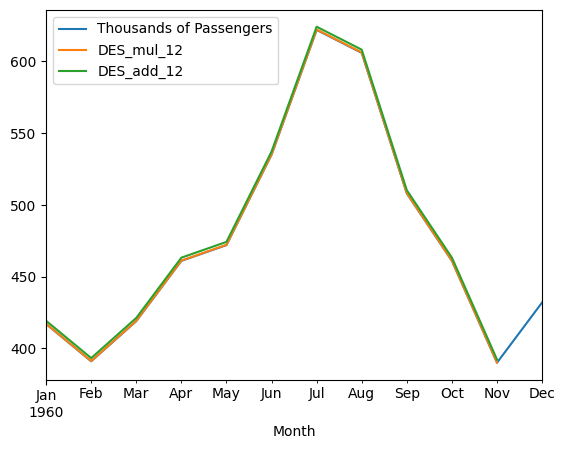

In [40]:
airline[["Thousands of Passengers", "DES_mul_12", "DES_add_12"]].iloc[-12:].plot() # for recent data add and mul perform quite similar

In [ ]:
# Triple Exponential Smoothing
# we use trend mul since we have found out that it performs better
# we set seasonal mul to indicate that changes in seasonality are growing proportional
airline["TES_mul_12"] = ExponentialSmoothing(airline["Thousands of Passengers"], trend="mul", seasonal="mul", seasonal_periods=12).fit().fittedvalues.shift(-1)

<Axes: xlabel='Month'>

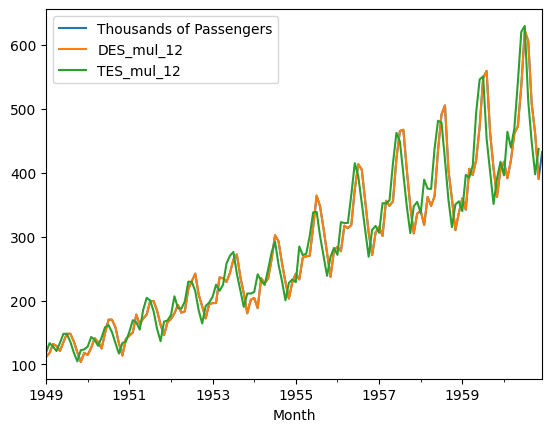

In [ ]:
airline[["Thousands of Passengers", "DES_mul_12", "TES_mul_12"]].plot()
# it is true that TES perform worse than DES when it comes to replicate the past history, but we will have to focus in forecasting in the next examples